# Initialising the FC benchmarker


The path to the Git repository containing the FC implementation. This should be
changed to reflect where in your system you have saved this.


In [1]:
PATH_TO_REPOSITORY = "/home/ahutton/dev/uni/Part D Project/fc-implementation"

Using the default build and run commands. These are configured to build and run
the Rust FC implementation using `cargo`.


In [2]:
import marker
benchmark_runner = marker.Benchmarker(PATH_TO_REPOSITORY)

You can list all the local branches available in the repository


In [3]:
benchmark_runner.repo.list_branches()

['factor-trimming',
 'factor-trimming-no-collect',
 'factor-trimming-no-universe-check',
 'ft-nuc-ahash',
 'ft-nuc-fxhash',
 'ft-nuc-nohash',
 'ft-nuc-nohash-lcp',
 'ft-nuc-nohash-lcp-enum',
 'groundup',
 'groundup-lcp',
 'groundup-lcp-join',
 'groundup-lcp-join-heuristics',
 'groundup-lcp-join-nc-heuristics',
 'groundup-lcp-join-temp',
 'groundup-lcp-memo',
 'groundup-lcp-memo-heuristics',
 'groundup-lcp-nc-heuristics',
 'groundup-lcp-pregen',
 'lcp',
 'lcp-factors',
 'list',
 'main',
 'naive',
 'naive-no-collect',
 'naive-no-universe-check',
 'nc-nuc',
 'nc-nuc-nohash',
 'parallel']

# Running your first benchmark


A simple first example, determining if the given words are squares


In [4]:
from marker.cases import fc_test_cases

word1 = "aa"
word2 = "hellohello"
word3 = "bananabananabananabanana"
formula = '$U = x x && ¬x = ""'

# Compare the join-approach and the elimination-approach
branches = ["main", "groundup-lcp-nc-heuristics"]

results = benchmark_runner.benchmark_branches(
    cases=fc_test_cases(formula, word1, word2, word3),
    branches=branches
)

0
*********************** Branch main ***********************
A	.cargo/config.toml
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your local commits)


Switched to branch 'main'
   Compiling fc-implementation v0.1.0 (/home/ahutton/dev/uni/Part D Project/fc-implementation)
 --> src/formula.rs:2:5
  |
2 | use crate::print_assignments;
  |     ^^^^^^^^^^^^^^^^^^^^^^^^
  |
  = note: `#[warn(unused_imports)]` (part of `#[warn(unused)]`) on by default

   --> src/main.rs:168:53
    |
168 | fn print_assignments(assignments: &Vec<Assignment>, universe: &str, column_width: usize) -> usize {
    |                                                     ^^^^^^^^ help: if this is intentional, prefix it with an underscore: `_universe`
    |
    = note: `#[warn(unused_variables)]` (part of `#[warn(unused)]`) on by default

   --> src/strutils.rs:215:8
    |
215 | pub fn count_chars(string: &str) -> usize {
    |        ^^^^^^^^^^^
    |
    = note: `#[warn(dead_code)]` (part of `#[warn(unused)]`) on by default

    Finished ]8;;https://doc.rust-lang.org/cargo/reference/profiles.html#default-profiles\`release` profile [optimized + debuginfo]]8;;\ ta

Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', '$U = x x && ¬x = ""', '--text', 'aa']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', '$U = x x && ¬x = ""', '--text', 'hellohello']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', '$U = x x && ¬x = ""', '--text', 'bananabananabananabanana']
['/tmp/parkbench/run_0.csv', '/tmp/parkbench/run_1.csv', '/tmp/parkbench/run_2.csv']
*********************** Branch groundup-lcp-nc-heuristics ***********************
A	.cargo/config.toml
Your branch is ahead of 'origin/groundup-lcp-nc-heuristics' by 1 commit.
  (use "git push" to publish your local commits)


   --> src/main.rs:169:53
    |
169 | fn print_assignments(assignments: &Vec<Assignment>, universe: &str, column_width: usize) -> usize {
    |                                                     ^^^^^^^^ help: if this is intentional, prefix it with an underscore: `_universe`
    |
    = note: `#[warn(unused_variables)]` (part of `#[warn(unused)]`) on by default

   --> src/strutils.rs:215:8
    |
215 | pub fn count_chars(string: &str) -> usize {
    |        ^^^^^^^^^^^
    |
    = note: `#[warn(dead_code)]` (part of `#[warn(unused)]`) on by default



Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', '$U = x x && ¬x = ""', '--text', 'aa']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', '$U = x x && ¬x = ""', '--text', 'hellohello']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', '$U = x x && ¬x = ""', '--text', 'bananabananabananabanana']
['/tmp/parkbench/run_0.csv', '/tmp/parkbench/run_1.csv', '/tmp/parkbench/run_2.csv']


    Finished ]8;;https://doc.rust-lang.org/cargo/reference/profiles.html#default-profiles\`release` profile [optimized + debuginfo]]8;;\ target(s) in 1.10s


Note that the build warnings reflect code that is required by other implementations, but are unused by these ones. They will not effect performance, as unused code is not included by the compiler.

## Plotting Results


Now we can simply plot the time taken for the two implementations to decide each
case


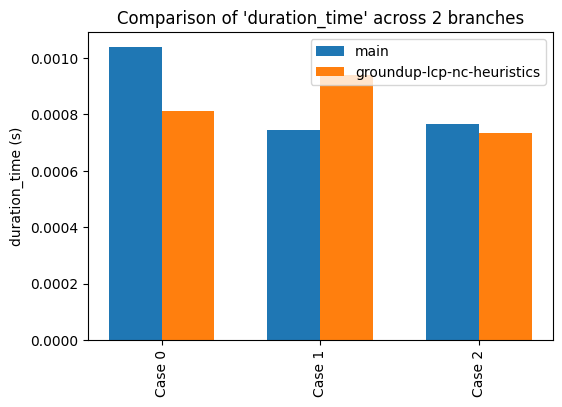

In [5]:
from marker.perf import plot_results, PerfEvent
plot_results(PerfEvent.DURATION_TIME, results)

# A more complex example


Consider a CSV-inspired format, representing a table, where rows are separated
by semi-colons (instead of new lines), and cells are separated by commas.

For example, the table below is represented by the string
`;hello,there;banana,apple;`

| "hello"  | "there" |
| -------- | ------- |
| "banana" | "apple" |

The formula used will assume there are exactly two columns.

The FC-formula recognising such tables, and extracting their row contents as the
variable $c$ is:

$$
l =  c \doteq a \texttt{,} b \land \texttt{;} c \texttt{;} \land \neg \exists p, s : c \doteq p \texttt{;} s \land \neg \exists p, s : a \doteq p \texttt{,} s
$$


In [6]:
formula = 'c=a "," b && l=";"c";" && ¬exists p exists s  c = p ";"  s && ¬exists p exists s  a = p "," s'

words = [
    ';aa,cc;11,22;something here,more content;',
    ';aa,cc;11,22;something here,more content;hello,there',
    ';aasdasda,ccasdasdas;1sdasda1,23asd21as3d2;something here,more content;'
]

results = benchmark_runner.benchmark_branches(
    cases=[*fc_test_cases(formula, *words),
           ],
    branches=branches,
    num_trials=3,
    timeout=120,
)

Switched to branch 'main'
   Compiling fc-implementation v0.1.0 (/home/ahutton/dev/uni/Part D Project/fc-implementation)
 --> src/formula.rs:2:5
  |
2 | use crate::print_assignments;
  |     ^^^^^^^^^^^^^^^^^^^^^^^^
  |
  = note: `#[warn(unused_imports)]` (part of `#[warn(unused)]`) on by default



0
*********************** Branch main ***********************
A	.cargo/config.toml
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your local commits)


   --> src/main.rs:168:53
    |
168 | fn print_assignments(assignments: &Vec<Assignment>, universe: &str, column_width: usize) -> usize {
    |                                                     ^^^^^^^^ help: if this is intentional, prefix it with an underscore: `_universe`
    |
    = note: `#[warn(unused_variables)]` (part of `#[warn(unused)]`) on by default

   --> src/strutils.rs:215:8
    |
215 | pub fn count_chars(string: &str) -> usize {
    |        ^^^^^^^^^^^
    |
    = note: `#[warn(dead_code)]` (part of `#[warn(unused)]`) on by default

    Finished ]8;;https://doc.rust-lang.org/cargo/reference/profiles.html#default-profiles\`release` profile [optimized + debuginfo]]8;;\ target(s) in 1.11s
Switched to branch 'groundup-lcp-nc-heuristics'
   Compiling fc-implementation v0.1.0 (/home/ahutton/dev/uni/Part D Project/fc-implementation)
  --> src/main.rs:11:5
   |
11 | use itertools::Itertools;
   |     ^^^^^^^^^^^^^^^^^^^^
   |
   = note: `#[warn(unused_imports)]` (part of

Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'c=a "," b && l=";"c";" && ¬exists p exists s  c = p ";"  s && ¬exists p exists s  a = p "," s', '--text', ';aa,cc;11,22;something here,more content;']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'c=a "," b && l=";"c";" && ¬exists p exists s  c = p ";"  s && ¬exists p exists s  a = p "," s', '--text', ';aa,cc;11,22;something here,more content;hello,there']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'c=a "," b && l=";"c";" && ¬exists p exists s  c = p ";"  s && ¬exists p exists s  a = p "," s', '--text', ';aasdasda,ccasdasdas;1sdasda1,23asd21as3d2;something here,more content;']
['/tmp/parkbench/run_0.csv', '/tmp/parkbench/run_1.csv', '/tmp/parkbench/run_2.csv']
*********************** Branch groundup-lcp-nc-heuristics ***********************
A	.cargo/config.toml
Your branch is ahead of 'origin/groundup-lcp-nc-heuristics' by 1 commit.
  (use "git push"

   --> src/main.rs:169:53
    |
169 | fn print_assignments(assignments: &Vec<Assignment>, universe: &str, column_width: usize) -> usize {
    |                                                     ^^^^^^^^ help: if this is intentional, prefix it with an underscore: `_universe`
    |
    = note: `#[warn(unused_variables)]` (part of `#[warn(unused)]`) on by default

   --> src/strutils.rs:215:8
    |
215 | pub fn count_chars(string: &str) -> usize {
    |        ^^^^^^^^^^^
    |
    = note: `#[warn(dead_code)]` (part of `#[warn(unused)]`) on by default

    Finished ]8;;https://doc.rust-lang.org/cargo/reference/profiles.html#default-profiles\`release` profile [optimized + debuginfo]]8;;\ target(s) in 1.07s


Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'c=a "," b && l=";"c";" && ¬exists p exists s  c = p ";"  s && ¬exists p exists s  a = p "," s', '--text', ';aa,cc;11,22;something here,more content;']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'c=a "," b && l=";"c";" && ¬exists p exists s  c = p ";"  s && ¬exists p exists s  a = p "," s', '--text', ';aa,cc;11,22;something here,more content;hello,there']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'c=a "," b && l=";"c";" && ¬exists p exists s  c = p ";"  s && ¬exists p exists s  a = p "," s', '--text', ';aasdasda,ccasdasdas;1sdasda1,23asd21as3d2;something here,more content;']
['/tmp/parkbench/run_0.csv', '/tmp/parkbench/run_1.csv', '/tmp/parkbench/run_2.csv']


It is good practice to save the results, so they can be loaded later


In [7]:
import json

with open("./results.json", "w") as f:
    json.dump(results, f)

In [8]:
# Uncomment to load previous JSON results
# with open("./results.json") as f:
#     results = json.load(f)

When plotting the results, we can customise the output graph by passing further
options to `plot_results`.


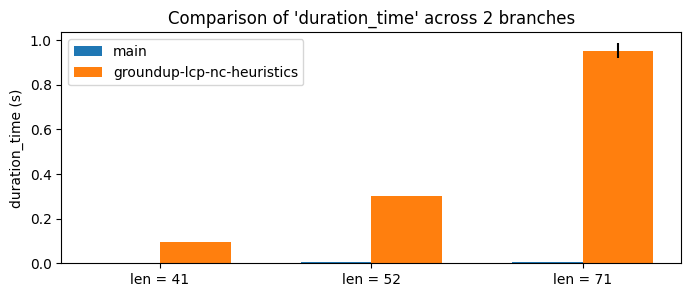

In [9]:
case_labels = [f"len = {len(w)}" for w in words]

plot_results(PerfEvent.DURATION_TIME, results, case_labels=case_labels, x_rotation=0, dimensions=(8, 3))

We can hardly see the results from the `main` branch, perhaps a logarithmic
scale on the y-axis would help.


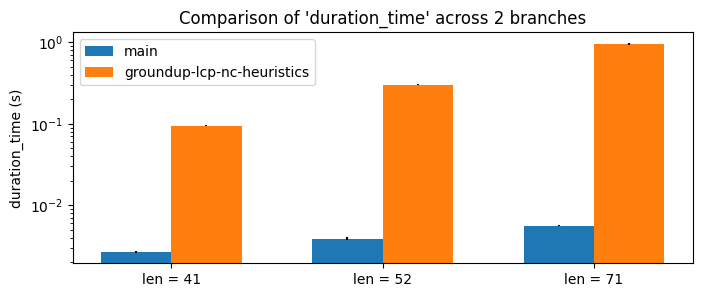

In [10]:
plot_results(PerfEvent.DURATION_TIME, results, case_labels=case_labels, x_rotation=0, dimensions=(8, 3), log_scale=True)

Further customisation can be made by using `matplotlib` directly


Text(0.5, 1.0, 'Results for extracting CSV content')

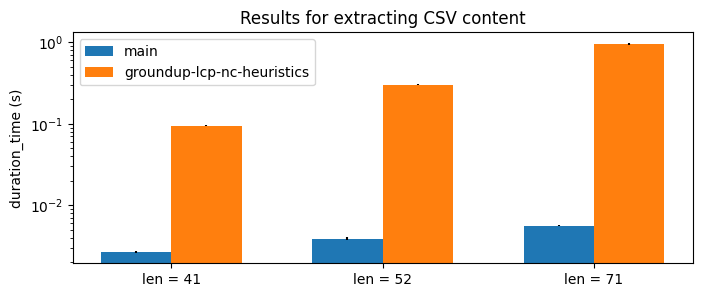

In [11]:
import matplotlib.pyplot as plt
plot_results(PerfEvent.DURATION_TIME, results, case_labels=case_labels, x_rotation=0, dimensions=(8, 3), log_scale=True)
plt.title("Results for extracting CSV content")

Finally, the graph can be saved using matplotlib


Saved file to ./plot.png


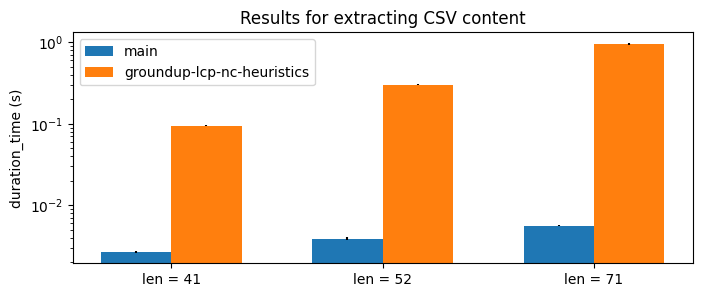

In [12]:
plot_results(PerfEvent.DURATION_TIME, results, case_labels=case_labels, x_rotation=0, dimensions=(8, 3), log_scale=True)
plt.title(label="Results for extracting CSV content")
plt.savefig("./plot.png")
print("Saved file to ./plot.png")